# Notebook 04: Entrenamiento y Predicción Espacial

## 1. Arquitectura del Modelo
Para predecir el Riesgo Epidemiológico Espacial, implementaremos un modelo de clasificación binaria utilizando **XGBoost (Extreme Gradient Boosting)**. Esta arquitectura es ideal para el Modelado de Nicho Ecológico (ENM) debido a su capacidad para capturar interacciones complejas y umbrales bioclimáticos no lineales sin asumir una distribución normal en los datos.

## 2. Métricas de Evaluación
Dado que trabajamos con datos de presencia-background (no ausencias verdaderas), la evaluación se realizará mediante:
*   **Curva ROC y AUC (Área Bajo la Curva):** Evalúa la capacidad del algoritmo para discriminar entre las condiciones óptimmas del parásito y el entorno general.
*   **Importancia de Variables (Feature Importance):** Cuantifica el peso matemático de la Temperatura vs. la Precipitación en el límite de expansión de la plaga.

## 3. Proyección Cartográfica
Una vez entrenado, el modelo dejará de evaluar tablas para evaluar tensores espaciales. Alimentaremos al algoritmo con el Raster continuo de México y Centroamérica píxel por píxel. El resultado será un mapa de calor predictivo que mapeará la probabilidad de supervivencia (0 a 1) en el territorio.

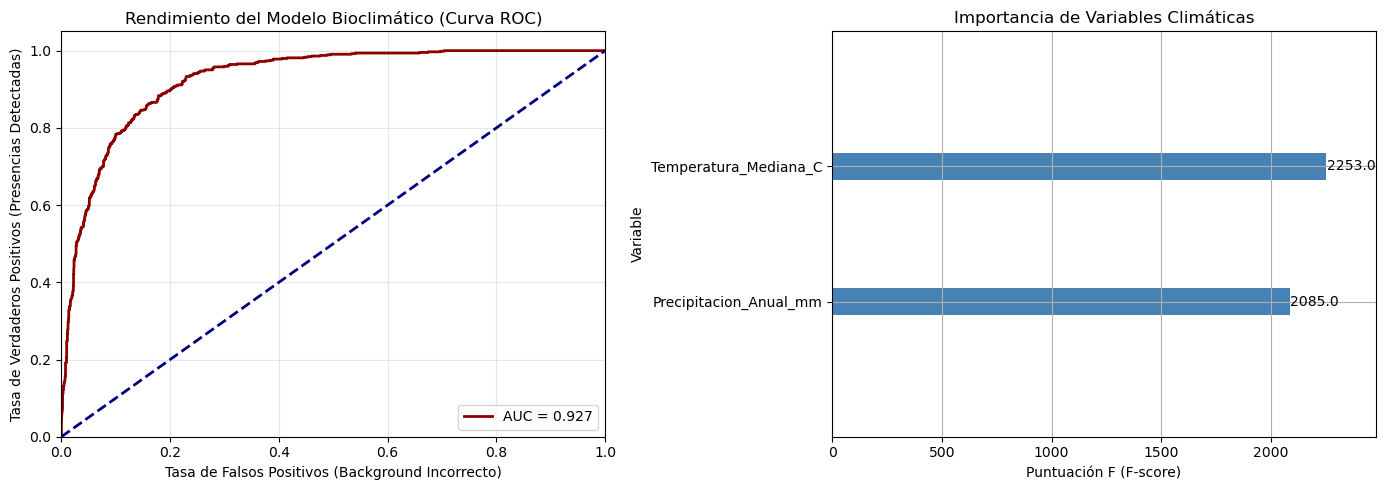

Modelo entrenado exitosamente con un AUC de: 0.927


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report
import os 

# cargar dataset de entrenamiento 
directorio_notebooks = os.getcwd()
directorio_raiz = os.path.dirname(directorio_notebooks)
ruta_datos = os.path.join(directorio_raiz, 'data', 'processed', 'Dataset_MaxEnt_Entrenamiento.csv')
df = pd.read_csv(ruta_datos)

X = df[['Temperatura_Mediana_C', 'Precipitacion_Anual_mm']] #variables de predicción
y = df['Target'] # variable objetivo

# División en Entrenamiento y Prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Configuración y Entrenamiento del Modelo XGBoost
modelo_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=200, 
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

modelo_xgb.fit(X_train, y_train)
y_pred_proba = modelo_xgb.predict_proba(X_test)[:, 1]

# Evaluación: Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Configuración Visual de Resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Curva ROC
ax1.plot(fpr, tpr, color='darkred', lw=2, label=f'AUC = {roc_auc:.3f}')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos (Background Incorrecto)')
ax1.set_ylabel('Tasa de Verdaderos Positivos (Presencias Detectadas)')
ax1.set_title('Rendimiento del Modelo (Curva ROC)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Gráfica 2: Importancia de las Variables
xgb.plot_importance(modelo_xgb, ax=ax2, color='steelblue', title='Importancia de Variables Climáticas', xlabel='Puntuación F (F-score)', ylabel='Variable')

plt.tight_layout()
plt.show()

print(f"Modelo entrenado exitosamente con un AUC de: {roc_auc:.3f}")

El modelo ha obtenido un AUC (area under the curve) de $0.927$, es capaz de diferenciar una frontera climática muy clara y realizar predicciones adecuadas.
LLa curva ROC es un gráfico que muestra el rendimiento de un modelo de clasificación binario, compara los verdaderos positivos contra los falsos positivos, el comportamiento de un modelo ideal es tener el 100% de verdaderos positivos (instancias donde el modelo dijo acierta un caso positivo) y un 0% de Falsos positivos (instancias donde el modelo se equivoca al dar un positivo). La línea azul representa un AUC de 0.5 siendo una representación de un modelo de azar. Un AUC superior a 0.9 sugiere las siguientes conclusiones:

- **Fronteras Biológicas Estrictas**: El gusano barrenador necesita condiciones de temperatura y humedad específicas que ha identificado de manera correcta el modelo.
- **Contraste del Background**: Muchos de los puntos aleatorios cayeron en zonas poco adecuadas para la supervivencia del gusano, el modelo aprendió rapidamente que cierto umbral de temperatura y de humedad evita la presencia del gusano, descartando zonas como desiertos o montañas frías. 

La segunda gráfica muestra una comparación de la importancia de las variables utilizadas, destacando que la Temperatura es ligeramente más iimportante que la Precipitación Acumulada, sin embargo, ambas son muy similares en magnitud lo que confirma el uso adecuado de las variables. 

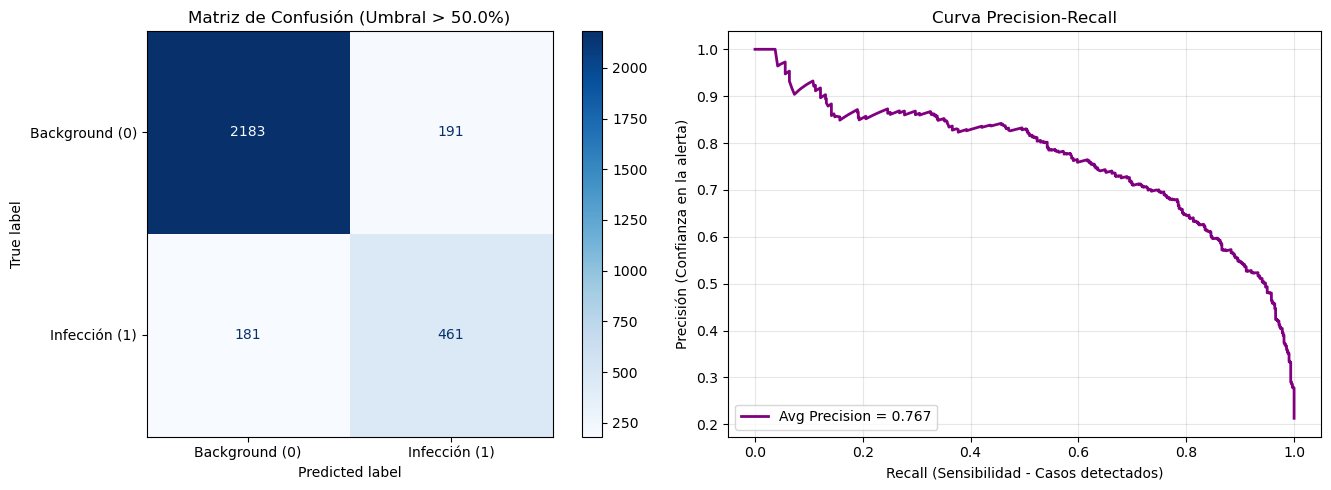

Reporte de Clasificación (Evaluando cada clase por separado):
                precision    recall  f1-score   support

Background (0)       0.92      0.92      0.92      2374
 Infección (1)       0.71      0.72      0.71       642

      accuracy                           0.88      3016
     macro avg       0.82      0.82      0.82      3016
  weighted avg       0.88      0.88      0.88      3016



In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score

# umbral tradicional para una matriz de confusión 
umbral = 0.50
y_pred_binario = (y_pred_proba >= umbral).astype(int)

# Construcción de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_binario)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background (0)', 'Infección (1)'])

# Construcción de la Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

# --- Configuración Visual ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Matriz de Confusión
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title(f'Matriz de Confusión (Umbral > {umbral*100}%)')

# Gráfica 2: Curva Precision-Recall
ax2.plot(recall, precision, color='purple', lw=2, label=f'Avg Precision = {avg_precision:.3f}')
ax2.set_xlabel('Recall (Sensibilidad - Casos detectados)')
ax2.set_ylabel('Precisión (Confianza en la alerta)')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir el reporte detallado que ignora el "Accuracy" engañoso
print("Reporte de Clasificación (Evaluando cada clase por separado):")
print(classification_report(y_test, y_pred_binario, target_names=['Background (0)', 'Infección (1)']))

Al evaluar el modelo XGBoost sobre el conjunto de prueba (Test Set), se obtuvo una **Precisión Promedio (Avg Precision) de 0.767** en la Curva PR, demostrando que el algoritmo tiene una alta confianza al clasificar las zonas habitables para el Gusano Barrenador, superando con creces la paradoja de clases desbalanceadas.

Del análisis de la Matriz de Confusión (con un umbral de decisión del 50%), extraemos las siguientes conclusiones epidemiológicas:

*   **Detección Efectiva (Verdaderos Positivos - 461 casos):** El modelo logró un *Recall* de 0.72 para la clase de Infección (1). Esto indica que el 72% de los brotes históricos pueden explicarse exclusivamente por la combinación de Temperatura Mediana y Precipitación Anual. El algoritmo capturó con éxito el núcleo del nicho ecológico.
*   **Vulnerabilidad Geográfica (Falsos Positivos - 191 casos):** Desde la perspectiva del Modelado de Nicho Ecológico (ENM), estos 191 registros no representan errores matemáticos, sino zonas de riesgo potencial. Corresponden a regiones de "pseudo-ausencia" donde el clima es idóneo para la supervivencia del parásito, pero donde (aún) no se han documentado brotes, marcando las rutas prioritarias para la vigilancia epidemiológica preventiva.
*   **Anomalías (Falsos Negativos - 181 casos):** Las zonas clasificadas por el modelo como inhóspitas pero que presentaron brotes sugieren la existencia de factores externos al clima, como el transporte de ganado infectado o microclimas artificiales (establos), lo cual es congruente con la dinámica de dispersión comercial de la ganadería.

**Conclusión del Entrenamiento:** 
Las métricas (F1-score de 0.71 y Accuracy global de 0.88) validan estadísticamente que el modelo ha aprendido la firma bioclimática de la plaga de forma robusta, justificando su uso para la proyección del Mapa de Calor Predictivo continental.

Por último se hará una **Proyección del Riesgo**. Tomaremos el mapa completo y lo entregamos al modelo entrenado. El algoritmo evalúa cada píxel de la imagen individualmente. Si el píxel coincide con la firma biológica, se le asignará una probabilidad cercana a 1, con condiciones climáticas hostiles se le dará un valor cercano a 0.

In [4]:
import rasterio
import os 

# Rutas de entrada y salida
directorio_notebooks = os.getcwd()
directorio_raiz = os.path.dirname(directorio_notebooks)
ruta_raster_clima = os.path.join(directorio_raiz, 'data', 'processed', 'Raster_Clima_GB.tif')
ruta_raster_riesgo = os.path.join(directorio_raiz, 'data', 'processed', 'Mapa_Riesgo_Barrenador_2026.tif')

with rasterio.open(ruta_raster_clima) as src:
    # Leer el entorno y la metadata para reconstruir la imagen después
    temp_matriz = src.read(1)
    precip_matriz = src.read(2)
    perfil = src.profile
    nodata_val = src.nodata

    # Aplanar las matrices a vectores 1D para alimentar a XGBoost
    temp_plano = temp_matriz.flatten()
    precip_plano = precip_matriz.flatten()

    # Crear una máscara matemática para ignorar el océano (NoData)
    mascara_tierra = (temp_plano != nodata_val) & (precip_plano != nodata_val) & \
                     (~np.isnan(temp_plano)) & (~np.isnan(precip_plano))

    # Preparar el dataframe solo con los píxeles de tierra firme
    df_tierra = pd.DataFrame({
        'Temperatura_Mediana_C': temp_plano[mascara_tierra],
        'Precipitacion_Anual_mm': precip_plano[mascara_tierra]
    })

    # PROYECCIÓN: Predecir el riesgo en todo el continente a la vez
    probabilidades_tierra = modelo_xgb.predict_proba(df_tierra)[:, 1]

    # Reconstruir el mapa (Matriz vacía rellenada con las probabilidades)
    riesgo_plano = np.full(temp_plano.shape, np.nan)
    riesgo_plano[mascara_tierra] = probabilidades_tierra

    # Devolver el vector a su forma bidimensional original (Alto x Ancho)
    matriz_riesgo_final = riesgo_plano.reshape(temp_matriz.shape)

    # Configurar el perfil del nuevo Raster para guardar las probabilidades
    perfil.update(
        dtype=rasterio.float32,
        count=1,
        nodata=np.nan
    )

    # Exportar el Mapa de Calor Predictivo
    with rasterio.open(ruta_raster_riesgo, 'w', **perfil) as dst:
        dst.write(matriz_riesgo_final.astype(rasterio.float32), 1)

print(f"✅ ¡Mapa térmico predictivo generado exitosamente en: {ruta_raster_riesgo}!")

✅ ¡Mapa térmico predictivo generado exitosamente en: C:\Users\Moises\gusano-barrenador-spatial-risk\data\processed\Mapa_Riesgo_Barrenador_2026.tif!


## Proyección Espacial: Mapa de Riesgo Epidemiológico (2026)

El siguiente mapa representa la proyección del modelo XGBoost sobre el territorio continuo. 
Cada píxel contiene un valor de probabilidad (de 0 a 1) que indica la idoneidad bioclimática para el establecimiento del **Gusano Barrenador del Ganado**. 

*   **Zonas Claras (Amarillo):** Barreras climáticas (desiertos o cordilleras frías) donde la probabilidad de supervivencia es casi nula.
*   **Zonas Oscuras (Rojo/Guinda):** Corredores de alto riesgo epidemiológico con las condiciones térmicas y pluviométricas exactas para detonar brotes severos.

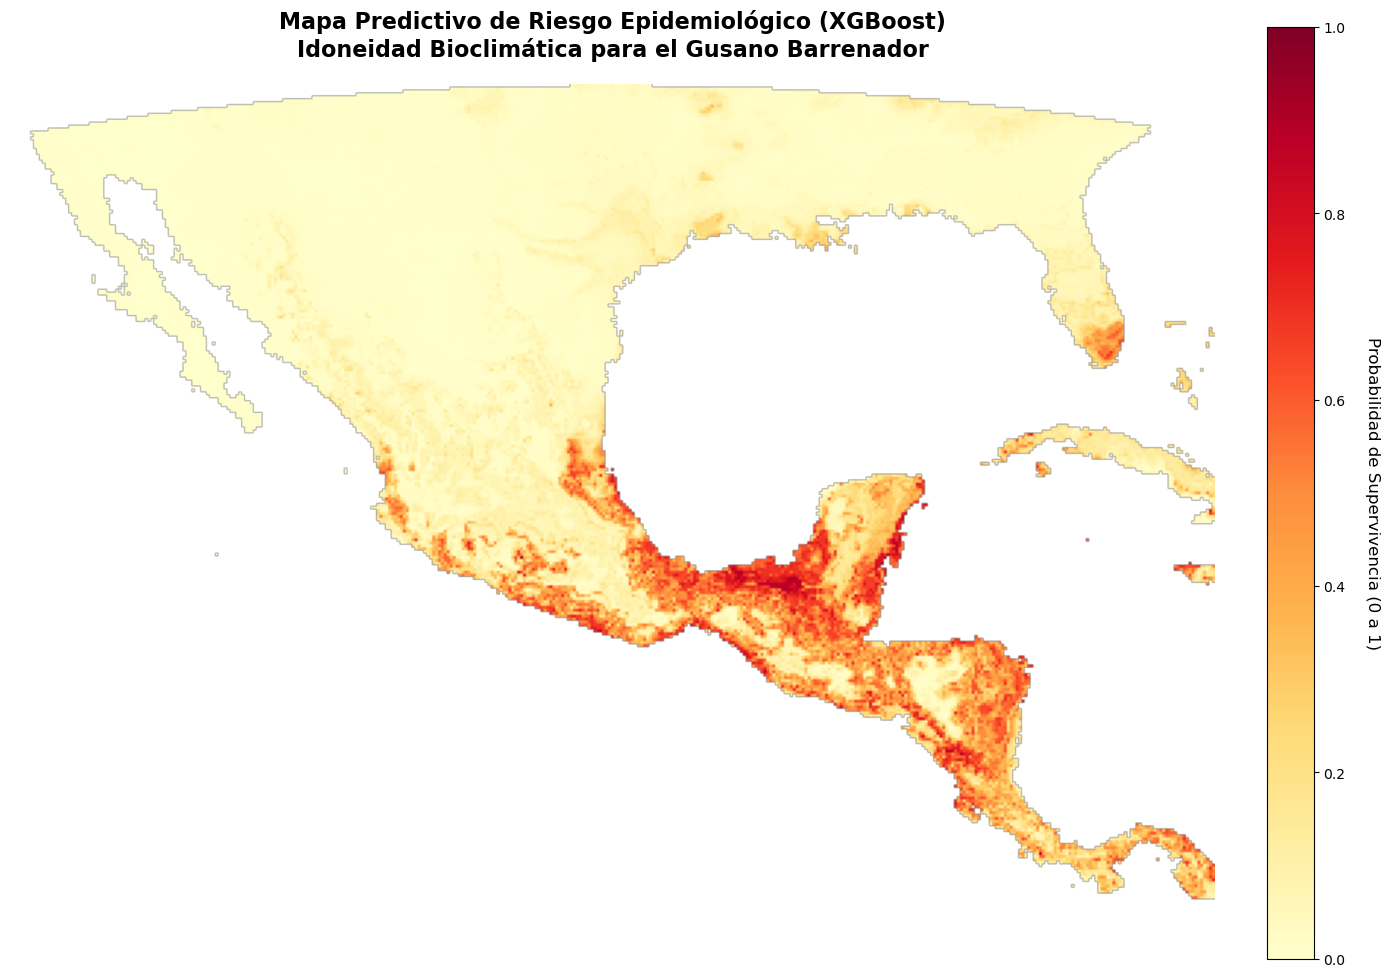

In [6]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os 

# Ruta del mapa 
directorio_notebooks = os.getcwd()
directorio_raiz = os.path.dirname(directorio_notebooks)
ruta_raster_riesgo = os.path.join(directorio_raiz, 'data', 'processed', 'Mapa_Riesgo_Barrenador_2026.tif')

try:
    with rasterio.open(ruta_raster_riesgo) as src:
        # Leemos la matriz de probabilidades
        matriz_riesgo = src.read(1)
        
        # Configuración del lienzo de alta calidad
        plt.figure(figsize=(14, 10))
        
        # Graficamos el mapa. 
        # Usamos 'YlOrRd' (Amarillo a Rojo) que es el estándar para mapas de riesgo epidemiológico
        # vmin=0 y vmax=1 aseguran que la escala represente porcentajes absolutos (0% a 100%)
        im = plt.imshow(matriz_riesgo, cmap='YlOrRd', vmin=0, vmax=1)
        
        # Título y diseño
        plt.title('Mapa Predictivo de Riesgo Epidemiológico (XGBoost)\nIdoneidad Bioclimática para el Gusano Barrenador', 
                  fontsize=16, fontweight='bold', pad=20)
        
        # Barra de escala de probabilidad
        cbar = plt.colorbar(im, fraction=0.036, pad=0.04)
        cbar.set_label('Probabilidad de Supervivencia (0 a 1)', rotation=270, labelpad=25, fontsize=12)
        
        # Limpieza visual (quitamos las coordenadas de los ejes)
        plt.axis('off')
        plt.tight_layout()
        
        # Mostrar el mapa interactivo
        plt.show()

except FileNotFoundError:
    print("Archivo no encontrado. Verifica que el bloque anterior haya guardado el mapa en la ruta correcta.")

## Discusión Metodológica: Clima Histórico vs. Pronóstico a Corto Plazo

**Justificación de las condiciones usadas (Uso de la Mediana y Lluvia Acumulada)**
El entrenamiento del ensamble XGBoost se fundamentó en la mediana térmica y la precipitación acumulada del periodo 2024-2025. En ecología espacial, la delimitación del Nicho Fundamental requiere métricas de tendencia central para evitar el sobreajuste (overfitting) a anomalías atmosféricas temporales. Entrenar el modelo con condiciones meteorológicas inmediatas generaría alertas de "oasis temporales", ignorando la viabilidad de establecimiento endémico a largo plazo de la plaga.

**Operatividad del Modelo para Alertas Tempranas (Forecasting)**
Es imperativo distinguir entre la fase de *Entrenamiento* (descubrimiento de la firma biológica) y la fase de *Inferencia* (proyección operativa). Dado que el algoritmo ha abstraído los umbrales absolutos de supervivencia de *Cochliomyia hominivorax*, la arquitectura actual es agnóstica a la temporalidad de los datos de entrada. 

Como trabajo futuro o despliegue en producción, este mismo modelo entrenado puede ingerir tensores de pronóstico meteorológico a corto plazo (ej. previsiones semanales) para generar mapas de alerta temprana dinámicos, respondiendo a la pregunta: *"Dadas las reglas biológicas aprendidas, ¿las condiciones de los próximos 15 días permitirán el avance de la plaga hacia nuevos territorios?"*